## Loading the Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from termcolor import colored

In [3]:
path= 'credit_risk_dataset.csv'
df= pd.read_csv(path)

## EDA

In [4]:
df.shape

(32581, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [7]:
df.dtypes.value_counts()

int64      5
object     4
float64    3
Name: count, dtype: int64

In [8]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [9]:
# questions to answer
# Are (Young / low income) people more likely to default.
# do bad loan_grades significantly affect the default status.
# are higher loan amount / interest rates increase the default probability.
# do people with stable jobs default less.

In [10]:
# our data studies the credit card default status of some unknown bank in an unknown location.
# no id or name in each record, some people could have taken many loans at the same time.

In [11]:
print('duplicated rows:',colored(df.duplicated().sum(),'yellow')) # 165 duplicated rows
df.drop_duplicates(inplace= True)

duplicated rows: 165


In [12]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [13]:
# segmenting the records based on unique identifier (a person)
df.duplicated(subset= ['person_age', 'person_income', 'person_home_ownership','person_emp_length',
                       'cb_person_default_on_file', 'cb_person_cred_hist_length']).sum()
# 3385 people took multiple loans at once.

3385

In [14]:
flag_identifier_cols= ['person_age', 'person_income', 'person_home_ownership','person_emp_length',
                       'cb_person_default_on_file', 'cb_person_cred_hist_length']
df['count']= df.groupby(flag_identifier_cols, dropna= False)['person_age'].transform('count')

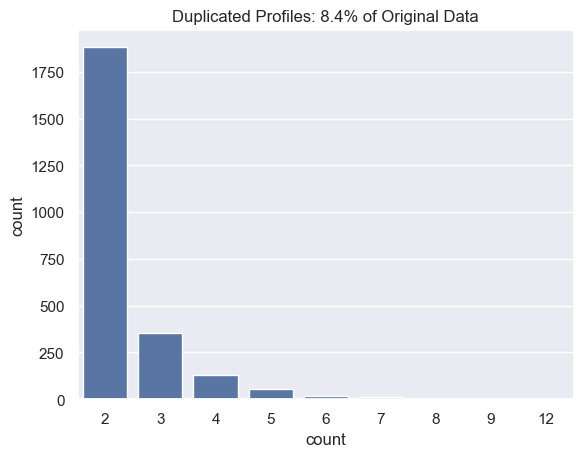

In [15]:
mask= df.duplicated(subset= flag_identifier_cols)
new_mask= df[~mask]['count'] > 1
percentage = round((len(df[~mask][new_mask]) / len(df[~mask])) * 100, 1)
plt.figure()
sns.countplot(data= df[~mask][new_mask], x= 'count')
plt.title(f'Duplicated Profiles: {percentage}% of Original Data')
plt.show()
# it appears around 8% of the records belong to people that took more than
# one loan at the same time, with around 1700 of them taking two loans at once,
# importance to keep in mind.

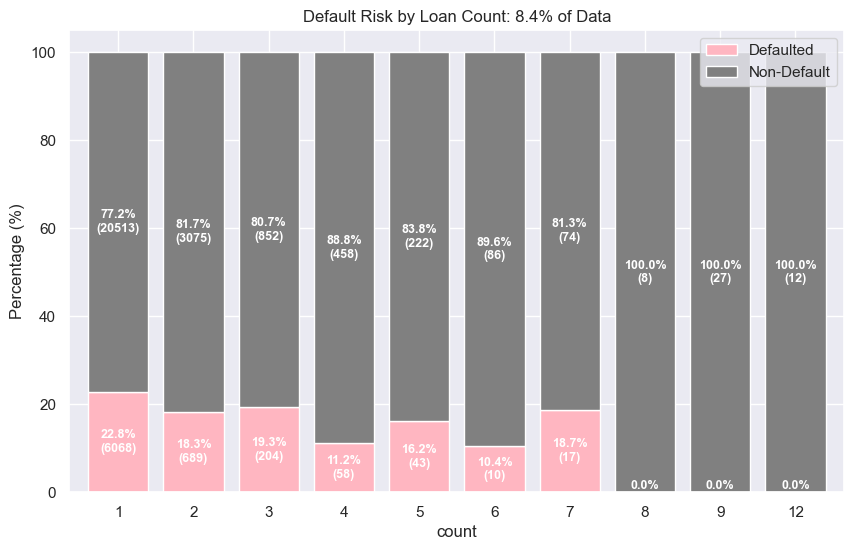

In [16]:
# 1. Prepare Dataframes (Percentages and Counts)
# We use [1, 0] to ensure Default (1) is the bottom/pink slice
pivot_pct = pd.crosstab(df['count'], df['loan_status'], normalize='index')[[1, 0]] * 100
pivot_cnt = pd.crosstab(df['count'], df['loan_status'])[[1, 0]]

plt.figure(figsize=(10, 6))
# Plotting with pink for Default (1) and grey for Non-Default (0)
pivot_pct.plot(kind='bar', stacked=True, color=['#FFB6C1', 'grey'], width=0.8, ax=plt.gca())

# 2. Add labels (Percentage + Raw Count)
for i, container in enumerate(plt.gca().containers):
    # Zip data to create 'X.X% (Count)' strings
    labels = [f'{p:.1f}%\n({c})' for p, c in zip(container.datavalues, pivot_cnt.iloc[:, i])]
    
    plt.gca().bar_label(container, labels=labels, label_type='center', 
                        color='white', fontweight='bold', fontsize=9)

plt.ylabel('Percentage (%)')
plt.title(f'Default Risk by Loan Count: {percentage}% of Data')
plt.xticks(rotation=0)
plt.legend(['Defaulted', 'Non-Default'], loc='upper right')
plt.show()

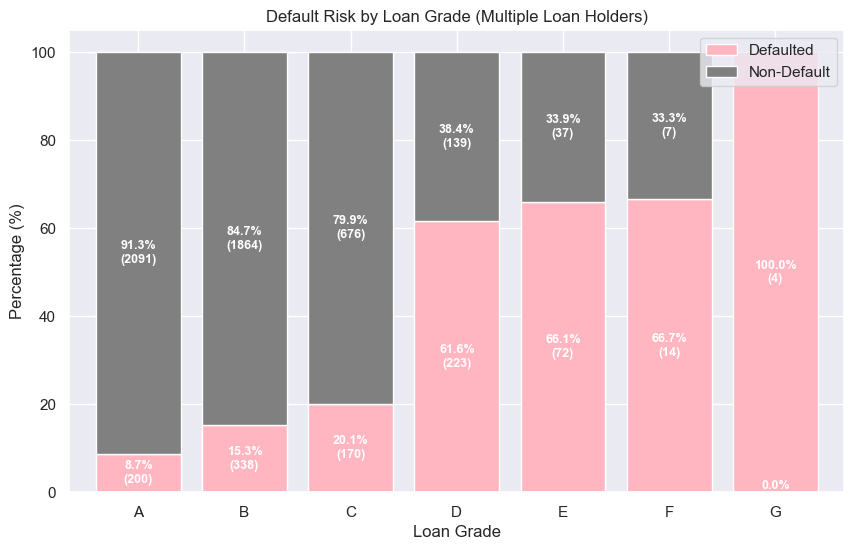

In [17]:
# 1. Filter and Create Cross-tabulation
multiple_loans_df = df[df['count'] > 1]
pivot_pct = pd.crosstab(multiple_loans_df['loan_grade'], multiple_loans_df['loan_status'], normalize='index')[[1, 0]] * 100
pivot_cnt = pd.crosstab(multiple_loans_df['loan_grade'], multiple_loans_df['loan_status'])[[1, 0]]

# 2. Plotting
plt.figure(figsize=(10, 6))
pivot_pct.plot(kind='bar', stacked=True, color=['#FFB6C1', 'grey'], width=0.8, ax=plt.gca())

# 3. Add Labels (Percentage and Raw Count)
for i, container in enumerate(plt.gca().containers):
    labels = [f'{p:.1f}%\n({c})' for p, c in zip(container.datavalues, pivot_cnt.iloc[:, i])]
    plt.gca().bar_label(container, labels=labels, label_type='center', 
                        color='white', fontweight='bold', fontsize=9)

plt.ylabel('Percentage (%)')
plt.xlabel('Loan Grade')
plt.title('Default Risk by Loan Grade (Multiple Loan Holders)')
plt.xticks(rotation=0)
plt.legend(['Defaulted', 'Non-Default'])
plt.show()

In [18]:
df[df['count'] > 1].describe().round(1)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,count
count,5835.0,5835.0,5756.0,5835.0,5285.0,5835.0,5835.0,5835.0,5835.0
mean,24.5,57825.8,4.3,8907.2,10.3,0.2,0.2,3.8,2.7
std,3.3,27757.9,3.3,5619.7,3.0,0.4,0.1,2.3,1.3
min,21.0,5000.0,0.0,700.0,5.4,0.0,0.0,2.0,2.0
25%,22.0,40000.0,2.0,5000.0,7.7,0.0,0.1,2.0,2.0
50%,24.0,52000.0,4.0,8000.0,10.4,0.0,0.2,3.0,2.0
75%,25.0,70000.0,7.0,12000.0,12.4,0.0,0.2,4.0,3.0
max,47.0,400000.0,21.0,35000.0,21.7,1.0,0.7,17.0,12.0


In [19]:
print('freq:', len(df[(df['count']>1) & (df['loan_grade'].isin(['A','B','C']))]),'\n----------------')
print(df[(df['count']>1) & (df['loan_grade'].isin(['A','B','C']))]['loan_status'].value_counts(normalize= True).round(2))

freq: 5339 
----------------
loan_status
0    0.87
1    0.13
Name: proportion, dtype: float64


In [ ]:
new_cols= [col for col in df.columns if col != 'loan_status']+ ['loan_status']
df= df[new_cols]

**no clear trend showing people who took multiple loans at once have higher chances of defaults.**
**infact its the opposite, multiple loans with higher grades show a clear evidence that person is credit-worthy**

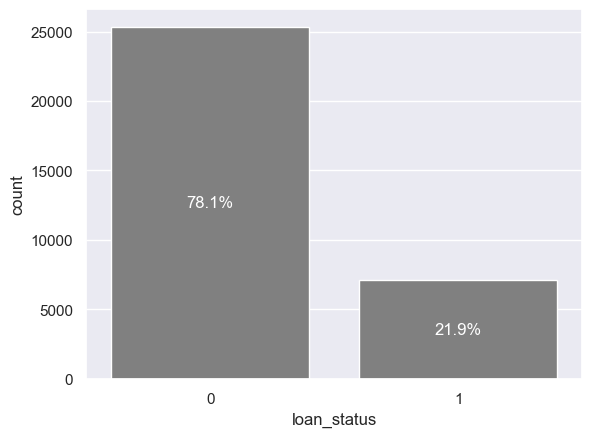

In [20]:
# target Y
plt.figure()
sns.countplot(data= df, x= 'loan_status', color= 'grey')
plt.gca().bar_label(plt.gca().containers[0], 
                    fmt=lambda x: f'{x/len(df):.1%}', 
                    label_type='center', 
                    color='white')
plt.show()
# we'll deal with this imbalance using smote-end technique

<h5 style="color:yellow", weight= "bold">Multi-variate Analysis</h5>

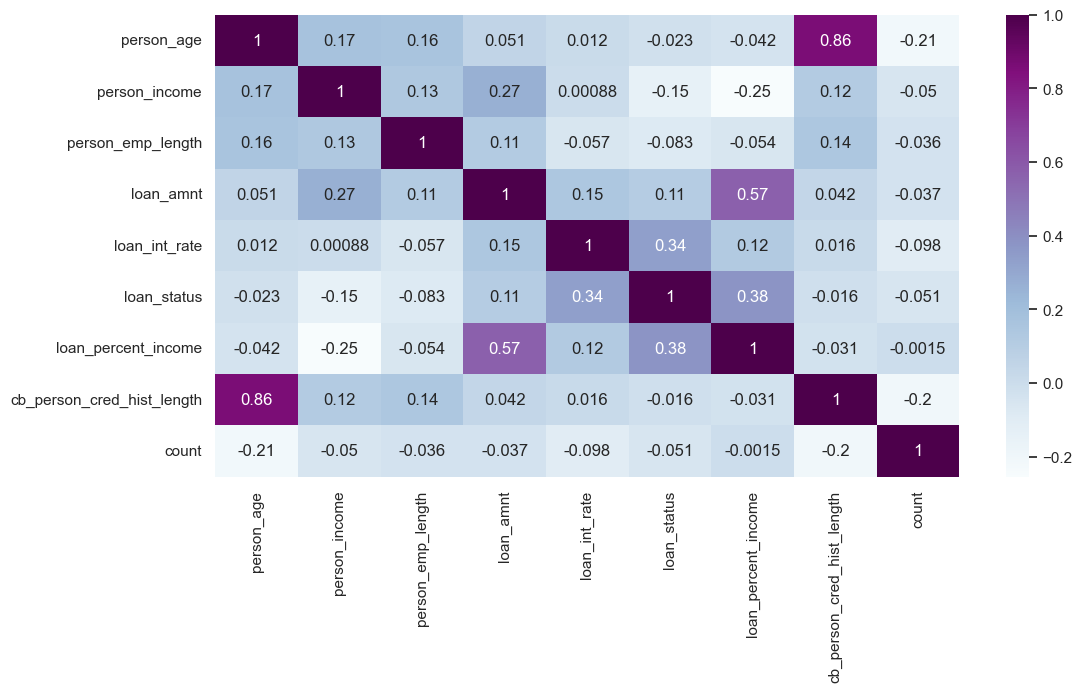

In [34]:
num_cols= df.select_dtypes(include='number')
plt.figure(figsize= (12, 6))
sns.heatmap(num_cols.corr(), cmap= 'BuPu', annot= True)
plt.show()

**Observing high correlation between 'cb_person_cred_hist_length / person_age', we'll drop the former later**

<Figure size 640x480 with 0 Axes>

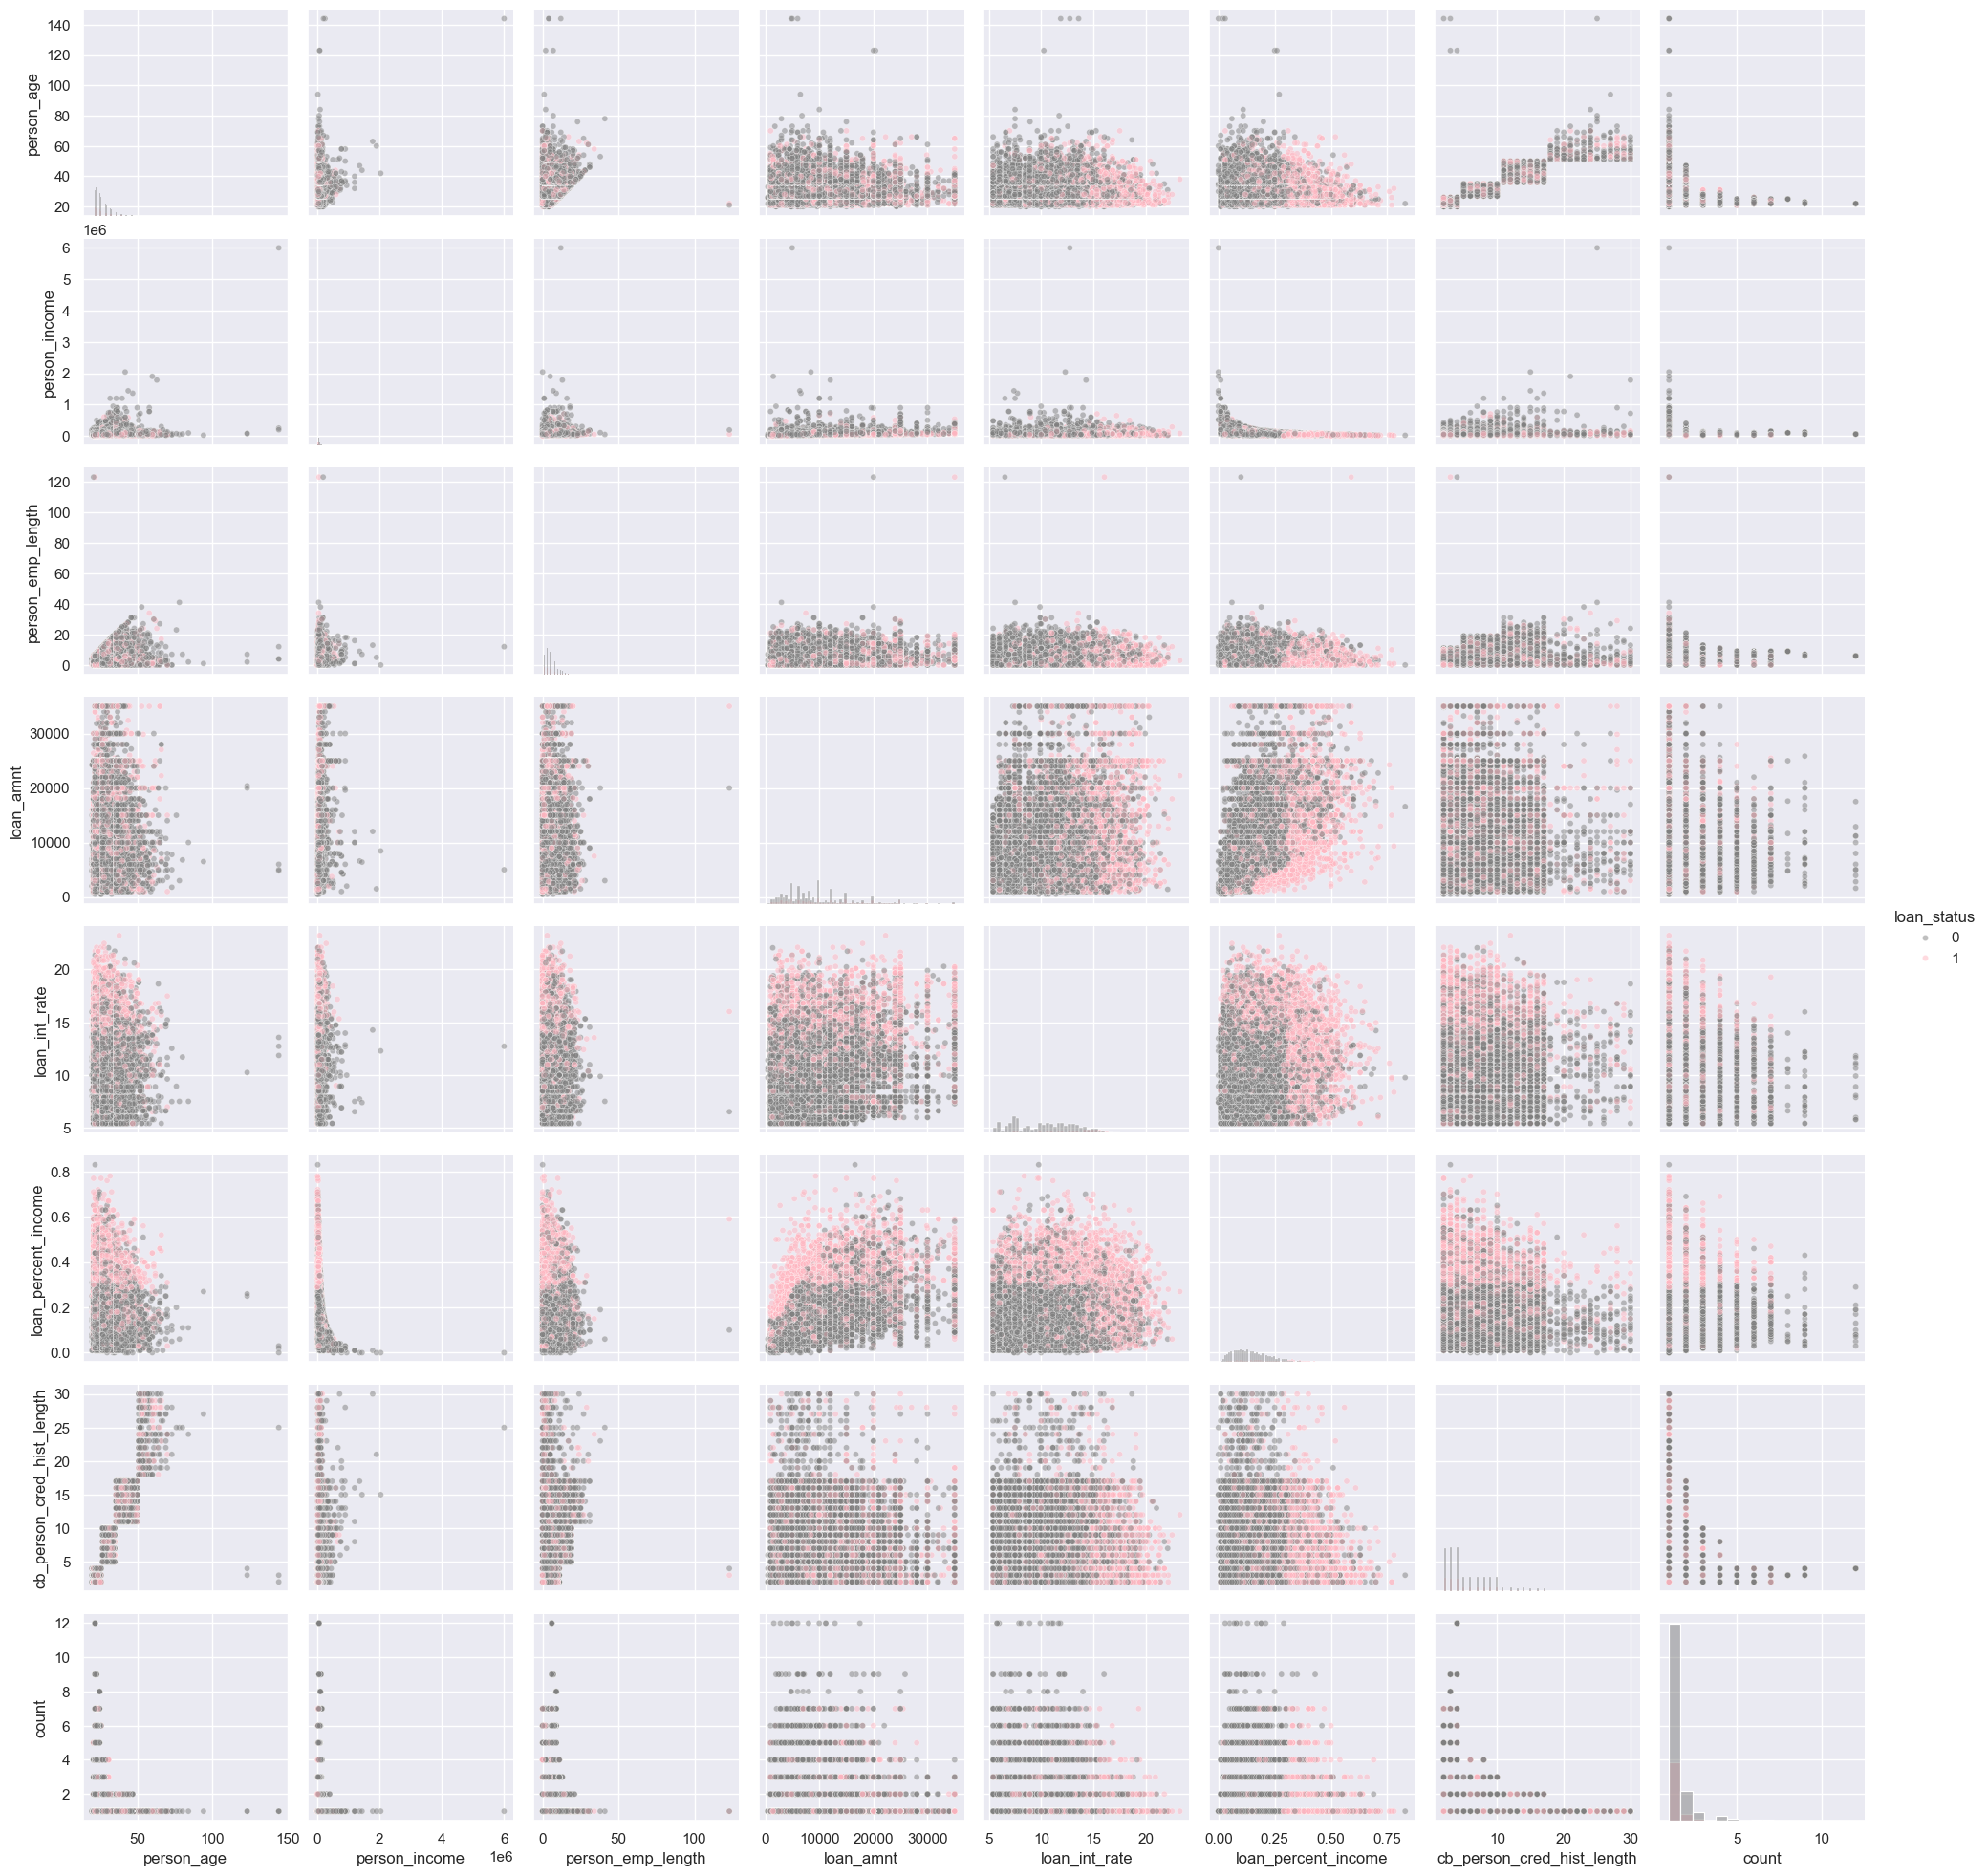

In [37]:
plt.figure()
sns.pairplot(num_cols, 
             hue='loan_status', 
             diag_kind='hist', 
             palette={0: 'grey', 1: '#FFB6C1'},
             plot_kws={'alpha': 0.5, 's': 20}) # S is dot size

plt.show()

<h5 style="color:yellow", weight= "bold">Flagging-outliers</h5>

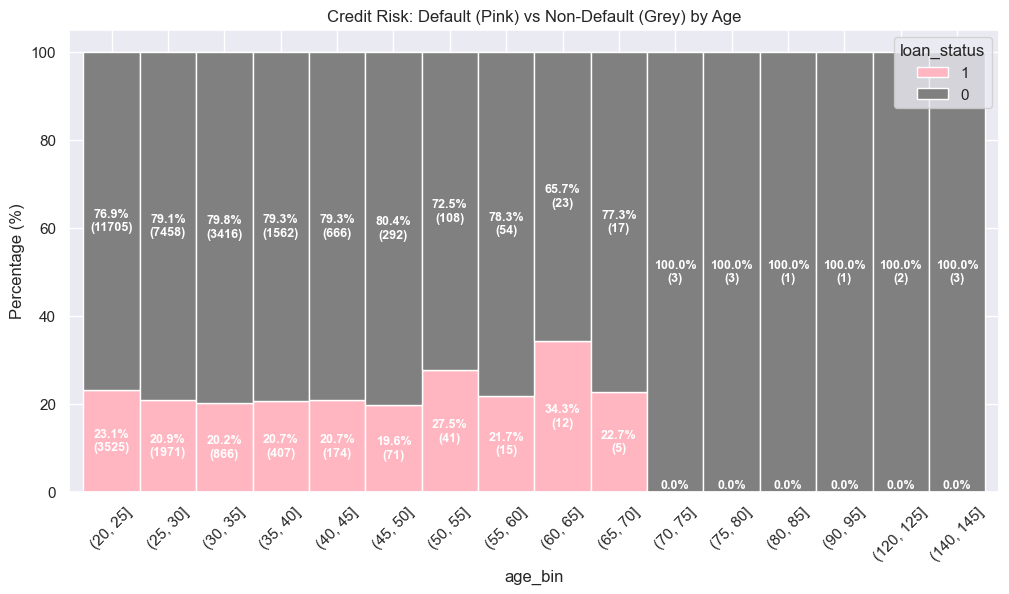

In [21]:
# 1. Bins and Dataframes (Percentages and Counts)
df['age_bin'] = pd.cut(df['person_age'], bins=range(20, int(df['person_age'].max()) + 6, 5))
pivot_pct = pd.crosstab(df['age_bin'], df['loan_status'], normalize='index')[[1, 0]] * 100
pivot_cnt = pd.crosstab(df['age_bin'], df['loan_status'])[[1, 0]]

plt.figure(figsize=(12, 6))
pivot_pct.plot(kind='bar', stacked=True, color=['#FFB6C1', 'grey'], width=1, ax=plt.gca())

# 2. Add labels using a loop to combine Pct and Count
for i, container in enumerate(plt.gca().containers):
    # Zip percentages from the plot with raw counts from our count table
    labels = [f'{p:.1f}%\n({c})' for p, c in zip(container.datavalues, pivot_cnt.iloc[:, i])]
    
    plt.gca().bar_label(container, labels=labels, label_type='center', 
                        color='white', fontweight='bold', fontsize=9)

plt.ylabel('Percentage (%)')
plt.title('Credit Risk: Default (Pink) vs Non-Default (Grey) by Age')
plt.xticks(rotation=45)
plt.show()

**no clear pattern linking age to default rates**

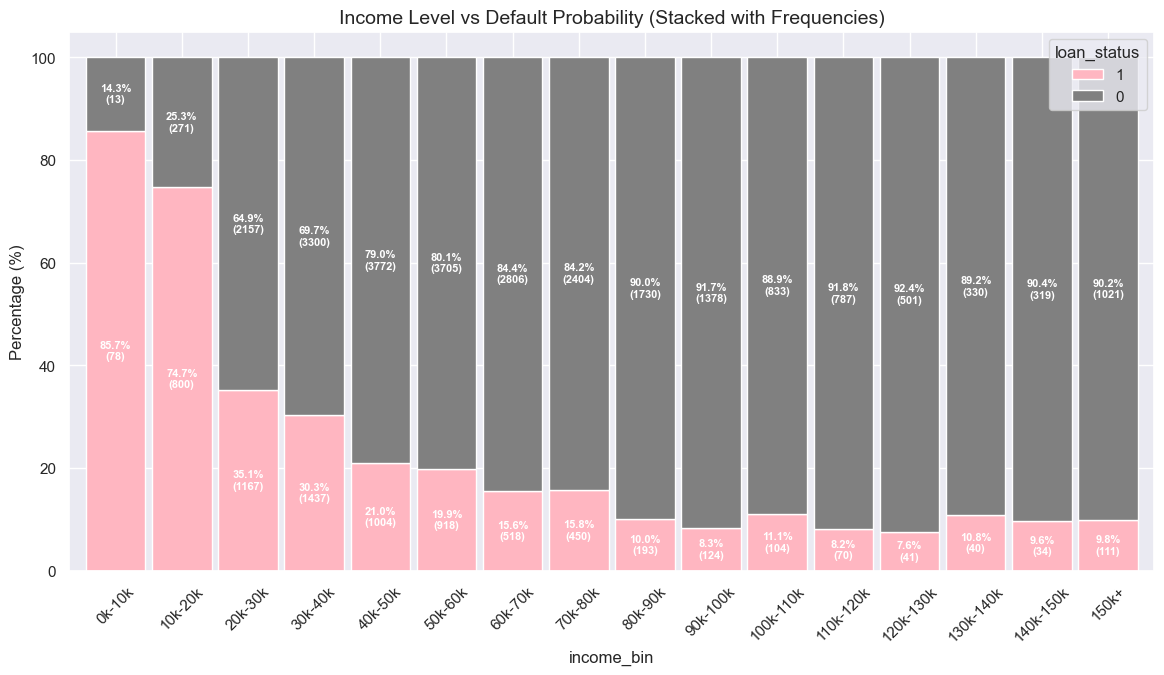

In [22]:
# 1. Bins and Labels
income_bins = list(range(0, 151001, 10000)) + [float('inf')]
income_labels = [f'{i//1000}k-{(i+10000)//1000}k' for i in range(0, 141000, 10000)] + ['150k+']
df['income_bin'] = pd.cut(df['person_income'], bins=income_bins, labels=income_labels)

# 2. Percentage and Count Tables
pivot_pct = pd.crosstab(df['income_bin'], df['loan_status'], normalize='index')[[1, 0]] * 100
pivot_cnt = pd.crosstab(df['income_bin'], df['loan_status'])[[1, 0]]

plt.figure(figsize=(14, 7))
pivot_pct.plot(kind='bar', stacked=True, color=['#FFB6C1', 'grey'], width=0.9, ax=plt.gca())

# 3. Combined Labels: Percentage + (Count)
for i, container in enumerate(plt.gca().containers):
    labels = [f'{p:.1f}%\n({c})' for p, c in zip(container.datavalues, pivot_cnt.iloc[:, i])]
    plt.gca().bar_label(container, labels=labels, label_type='center', 
                        color='white', fontweight='bold', fontsize=8)

plt.title('Income Level vs Default Probability (Stacked with Frequencies)', fontsize=14)
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.show()

**Individuals with low income show high default risk percentages, specifically those below 40k yearly income**

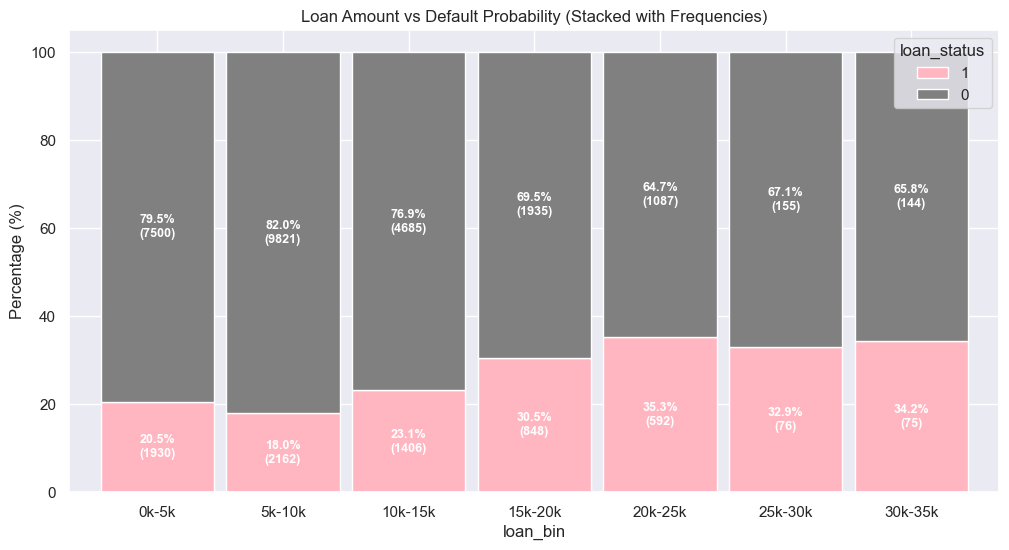

In [23]:
# 1. Binning
loan_bins = list(range(0, 35001, 5000))
loan_labels = [f'{i//1000}k-{(i+5000)//1000}k' for i in range(0, 35000, 5000)]
df['loan_bin'] = pd.cut(df['loan_amnt'], bins=loan_bins, labels=loan_labels)

# 2. Percentage and Count Dataframes
pivot_pct = pd.crosstab(df['loan_bin'], df['loan_status'], normalize='index')[[1, 0]] * 100
pivot_cnt = pd.crosstab(df['loan_bin'], df['loan_status'])[[1, 0]]

plt.figure(figsize=(12, 6))
pivot_pct.plot(kind='bar', stacked=True, color=['#FFB6C1', 'grey'], width=0.9, ax=plt.gca())

# 3. Combined Labels: % and (N)
for i, container in enumerate(plt.gca().containers):
    labels = [f'{p:.1f}%\n({c})' for p, c in zip(container.datavalues, pivot_cnt.iloc[:, i])]
    plt.gca().bar_label(container, labels=labels, label_type='center', 
                        color='white', fontweight='bold', fontsize=9)

plt.title('Loan Amount vs Default Probability (Stacked with Frequencies)')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.show()

**loans above 15k hold higher percentages of defaults compared to lowers ones.**

In [24]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,count,age_bin,income_bin,loan_bin
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,1,"(20, 25]",50k-60k,30k-35k
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,1,"(20, 25]",0k-10k,0k-5k
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,1,"(20, 25]",0k-10k,5k-10k
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,1,"(20, 25]",60k-70k,30k-35k
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,1,"(20, 25]",50k-60k,30k-35k


In [25]:
from IPython.display import display_html
high_loan_df = df[df['loan_amnt'] >= 15000]
grad_counts = high_loan_df['loan_grade'].value_counts().to_frame()
int_stats = high_loan_df['loan_int_rate'].describe().round(1).to_frame()

# 2. Style them to float left to right
df1_styler = grad_counts.style.set_table_attributes("style='display:inline; margin-right:20px;'").set_caption("Loan Grade Counts")
df2_styler = int_stats.style.set_table_attributes("style='display:inline; margin-right:20px;'").set_caption("Interest Rate Stats")
#age-bins loans holders abov 15k
age_frequencies= high_loan_df['person_age'].describe().round(1).to_frame()
#income bins of loan holders abov 15k
income_bin_frequencies= high_loan_df['income_bin'].value_counts().to_frame()
df3_style= age_frequencies.style.set_table_attributes("style='display:inline; margin-right:20px;'").set_caption('Age bins frequencies')
df4_style= income_bin_frequencies.style.set_table_attributes("style='display:inline;'").set_caption('income-bins frequencies')
# 3. Display
display_html(df1_styler._repr_html_() + df2_styler._repr_html_() + df3_style._repr_html_() + df4_style._repr_html_(), raw=True)

,count
loan_grade,
B,2364
A,1264
C,1242
D,967
E,409
F,122
G,40
,loan_int_rate
count,5819.000000


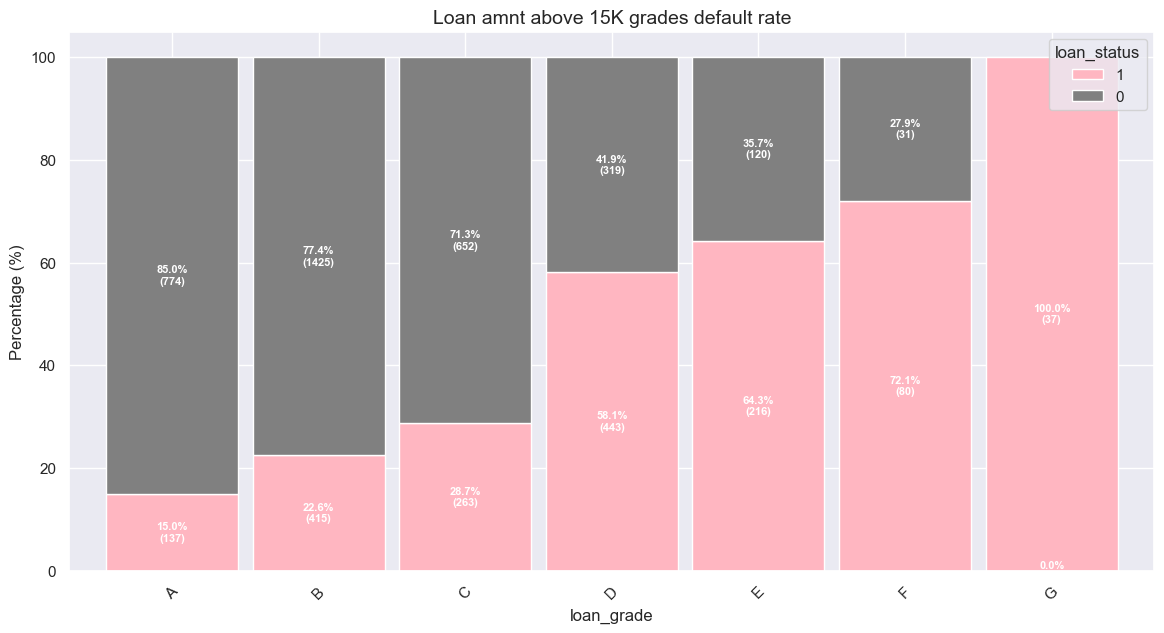

In [26]:
df_highloan= df[df['loan_amnt']>15000]
# 2. Percentage and Count Tables
pivot_pct = pd.crosstab(df_highloan['loan_grade'], df['loan_status'], normalize='index')[[1, 0]] * 100
pivot_cnt = pd.crosstab(df_highloan['loan_grade'], df['loan_status'])[[1, 0]]

plt.figure(figsize=(14, 7))
pivot_pct.plot(kind='bar', stacked=True, color=['#FFB6C1', 'grey'], width=0.9, ax=plt.gca())

# 3. Combined Labels: Percentage + (Count)
for i, container in enumerate(plt.gca().containers):
    labels = [f'{p:.1f}%\n({c})' for p, c in zip(container.datavalues, pivot_cnt.iloc[:, i])]
    plt.gca().bar_label(container, labels=labels, label_type='center', 
                        color='white', fontweight='bold', fontsize=8)

plt.title('Loan amnt above 15K grades default rate', fontsize=14)
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.show()

**it appears that bad loans are even worth looking into when the loan amnt exceeds 15k, (we cannot ignore them, due to evidence of high default rates).**

In [27]:
# are higher loan amount / interest rates increase the default probability.


int_rate_default = df[df['loan_status']== 1]['loan_int_rate'].describe().round(1).to_frame()
int_rate_non_default = df[df['loan_status']==0]['loan_int_rate'].describe().round(1).to_frame()

# 2. Style them to float left to right
df1_styler = int_rate_default.style.set_table_attributes("style='display:inline; margin-right:20px;'").set_caption("int_rate_default")
df2_styler = int_rate_non_default.style.set_table_attributes("style='display:inline;'").set_caption("int_rate_non_default")

display_html(df1_styler._repr_html_() + df2_styler._repr_html_(), raw=True)

,loan_int_rate
count,6448.000000
mean,13.100000
std,3.300000
min,5.400000
25%,10.700000
50%,13.500000
75%,15.600000
max,23.200000
,loan_int_rate
count,22873.000000


In [28]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length', 'count',
       'age_bin', 'income_bin', 'loan_bin'],
      dtype='object')

**clearly high interest rates are linked to high default rates**

In [29]:
# do people with stable jobs default less.

job_default = df[df['loan_status']== 1]['person_emp_length'].describe().round(1).to_frame()
job_non_default = df[df['loan_status']==0]['person_emp_length'].describe().round(1).to_frame()

# 2. Style them to float left to right
df1_styler = job_default.style.set_table_attributes("style='display:inline; margin-right:20px;'").set_caption("job_default")
df2_styler = job_non_default.style.set_table_attributes("style='display:inline;'").set_caption("job_non_default")

display_html(df1_styler._repr_html_() + df2_styler._repr_html_(), raw=True)

,person_emp_length
count,6808.000000
mean,4.100000
std,4.100000
min,0.000000
25%,1.000000
50%,3.000000
75%,6.000000
max,123.000000
,person_emp_length
count,24721.000000


**strong correlation showing unstable jobs linked with high default rates**

In [30]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,count,age_bin,income_bin,loan_bin
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,1,"(20, 25]",50k-60k,30k-35k
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,1,"(20, 25]",0k-10k,0k-5k
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,1,"(20, 25]",0k-10k,5k-10k
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,1,"(20, 25]",60k-70k,30k-35k
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,1,"(20, 25]",50k-60k,30k-35k


In [32]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length', 'count',
       'age_bin', 'income_bin', 'loan_bin'],
      dtype='object')

## Feature Engineering

In [ ]:
# features_to_add: age-bin, income-bin, loan_bin, count(loan_count_per-person_at a time),
def engineer_features(eng_data):
    flag_cols= ['person_age', 'person_income', 'person_home_ownership','person_emp_length',
                       'cb_person_default_on_file', 'cb_person_cred_hist_length']
    eng_data['count']= eng_data.groupby(flag_cols, drop_na= False)['peron_age'].transform('count')
    bins_income= list(range(0, 151_000, 10_000)) + [float('inf')]
    labels_income= [f'{i//1000}k-{(i+10_000)//1000}k' for i in range(0, 141_000, 10_000)] + ['150k+']
    eng_data['income_bin']= pd.cut(eng_data, bins= bins_income, labels= labels_income)
    
    return eng_data

In [68]:
Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['person_income'] < lower_bound) | (df['person_income'] > upper_bound)]

In [117]:
bins_income= list(range(0, 151_000, 10_000)) + [float('inf')]
labels_income= [f'{i//1000}k-{(i+10_000)//1000}k' for i in range(0, 141_000, 10_000)] + ['150k+']
alfa= df.copy()
alfa['binny']= pd.cut(alfa['person_income'], bins= bins_income, labels= labels_income)

## Preprocessing

## Model Selection

## Model Tunning